# Compute the nucleosome shift of the +1, and if possible, +2, and +3

May 8, 2024

Goal: Create a procedure to compute the shift of the +1 nucleosome.

1. First look at some examples of nucleosome positioning for various phases of the cell cycle. By eye is there a shift that is computable.
2. Design a procedure to compute the +1 nucleosome based on neighbor bins of nucleosome fragment length.
3. Compute the shift from the baseline +1 position for all genes.


In [10]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [11]:
from src.promoter_ptr_analysis import PromoterPTRAnalysis

chromatin_dir = 'output/deconvolve_combined_g_opt_2024_03_14/chromatin/'
promoter_analysis = PromoterPTRAnalysis(chromatin_dir)

In [18]:
promoter_analysis.load_f_files()

Shape of the loaded F: (227, 200)
1/5574 - 00:00:00.200
1001/5574 - 00:00:07.096
2001/5574 - 00:00:13.141
3001/5574 - 00:00:18.967
4001/5574 - 00:00:24.719
5001/5574 - 00:00:30.548


In [19]:
promoter_analysis.correct_f_images_by_strand()

In [20]:
promoter_analysis.strand_corrected_f_images.shape

(5578, 227, 8, 25)

In [33]:
from src.chromatin_metrics import len_bins

_, _, nuc_bins = len_bins()

nuc_bins = promoter_analysis.strand_corrected_f_images[:, :, nuc_bins[0]:nuc_bins[1]]
nuc_bins_sum = nuc_bins.sum(axis=2)

(5578, 227, 25)

In [ ]:
from src.gene_chromatin_replication_analysis import compute_plus_one_movement

In [219]:
config = load_yl_rg1_vst_config(1)
t_indices = config.get_Hpositions_for_branch('t')

geneset = promoter_analysis.geneset
gene_plus_one_position = pd.DataFrame(np.zeros((nuc_bins_sum.shape[0], 
    len(t_indices))),
    index=geneset.index)

for orf_name, gene in geneset.iterrows():    
    weighted_plus_one_pos = compute_plus_one_movement(gene, nuc_bins_sum, t_indices)
    gene_plus_one_position.loc[orf_name] = weighted_plus_one_pos
    

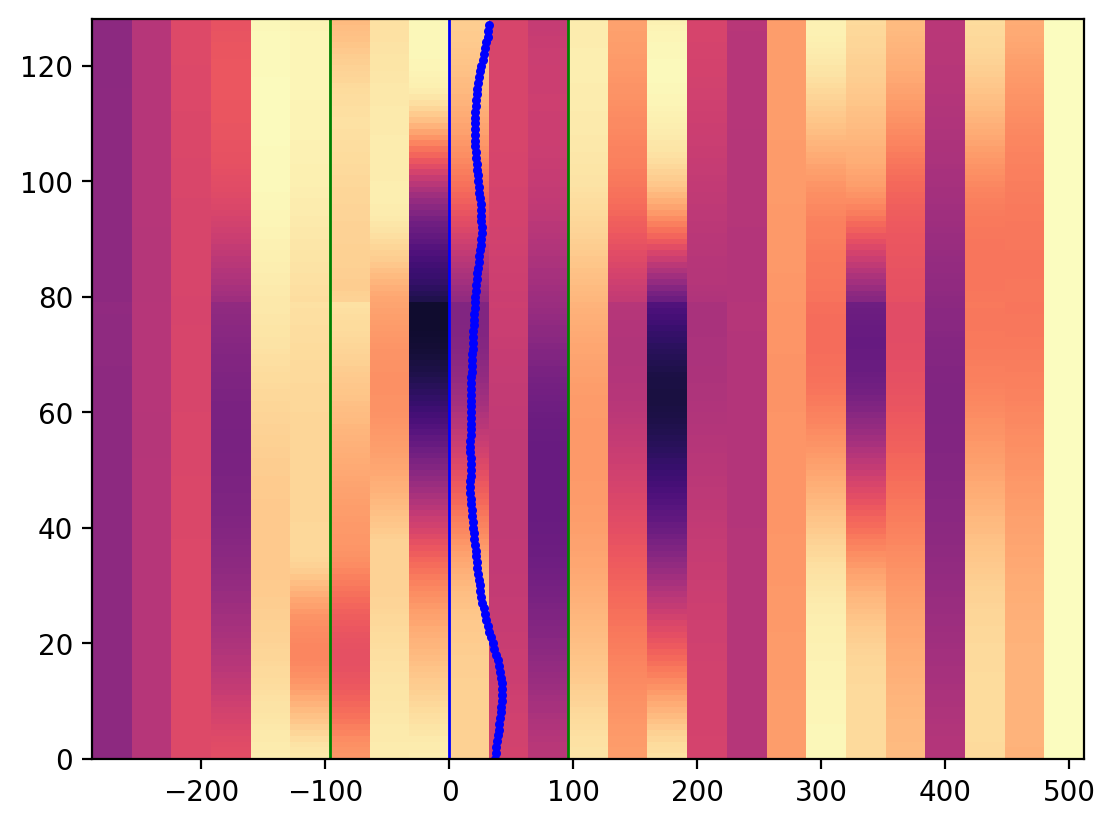

In [208]:
from src.config import load_yl_rg1_vst_config

plt.imshow(gene_nuc_bins[t_indices], aspect='auto', cmap='magma_r', vmax=30, vmin=0,
    extent=[-GlobalConstants.PROM_LEN, GlobalConstants.GB_LEN, 0, len(t_indices)])

plt.axvline(0, c='blue', lw=1, ls='solid')
plt.axvline(-GlobalConstants.BIN_WIDTH*3, c='green', lw=1, ls='solid')
plt.axvline(GlobalConstants.BIN_WIDTH*3, c='green', lw=1, ls='solid')

plt.scatter(weighted_avg_p1_pos, np.arange(len(prop_left)), s=5, c='blue')


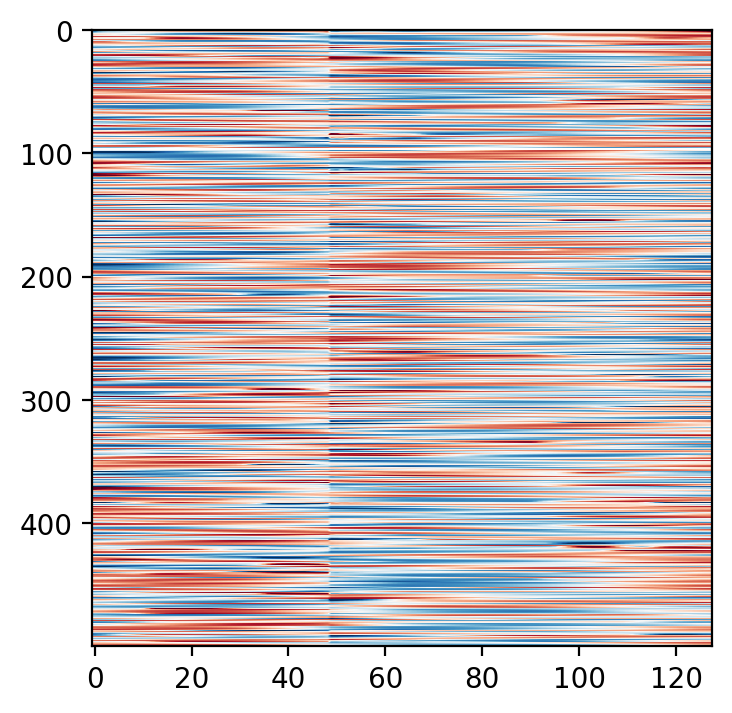

In [236]:
from scipy.stats import zscore

gene_plus_one_position = gene_plus_one_position.fillna(0)
gene_plus_one_position_z = zscore(gene_plus_one_position, axis=1)

plt.figure(figsize=(4, 4))
plt.imshow(gene_plus_one_position_z[:500], aspect='auto', vmin=-2, 
    vmax=2, cmap='RdBu_r')


In [234]:
gene_plus_one_position_z.to_csv('output/computed_plus_one_movement_znorm_2024_05_08.csv')
gene_plus_one_position.to_csv('output/computed_plus_one_movement_2024_05_08.csv')
